<center><h1>Lanka_VenkataSriSaiPavani_HW2</h1></center>
<br>
<br>

Name: Venkata Sri Sai Pavani Lanka
<br>
Github Username: lanka1908
<br>
USC ID: 4885549248

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [6]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import statistics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from scipy import stats
from statsmodels.stats.outliers_influence import OLSInfluence
import statsmodels.api as sm
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

Get the Cycle Power Plant Data Set

In [8]:
df = pd.read_excel('../data/CCPP/Folds5x2_pp.xlsx')
df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### (b) Exploring the data

#### i. rows and columns

In [11]:
print("size of the dataset", df.shape)
print("number of rows : ", df.shape[0])
print("number of columns : ", df.shape[1])

size of the dataset (9568, 5)
number of rows :  9568
number of columns :  5


The columns represent the features of the combined cycle power plant dataset.
Among the 5 columns, 4 of them represent the independent variables, which are: Ambient Temperature(AT)
Exhaust Vacuum(V)
Ambient Pressure(AP)
Relative Humdidty(RH)

These 4 variables are used to predict the net hourly electrical energy output(EP), which is the only dependent variable.

The rows of this dataset represent the data points collected from the power plant, where each row represents the the hourly observations recorded over the 6 years.(2006-2011)

#### ii. pairwise scatterplots of all the varianbles

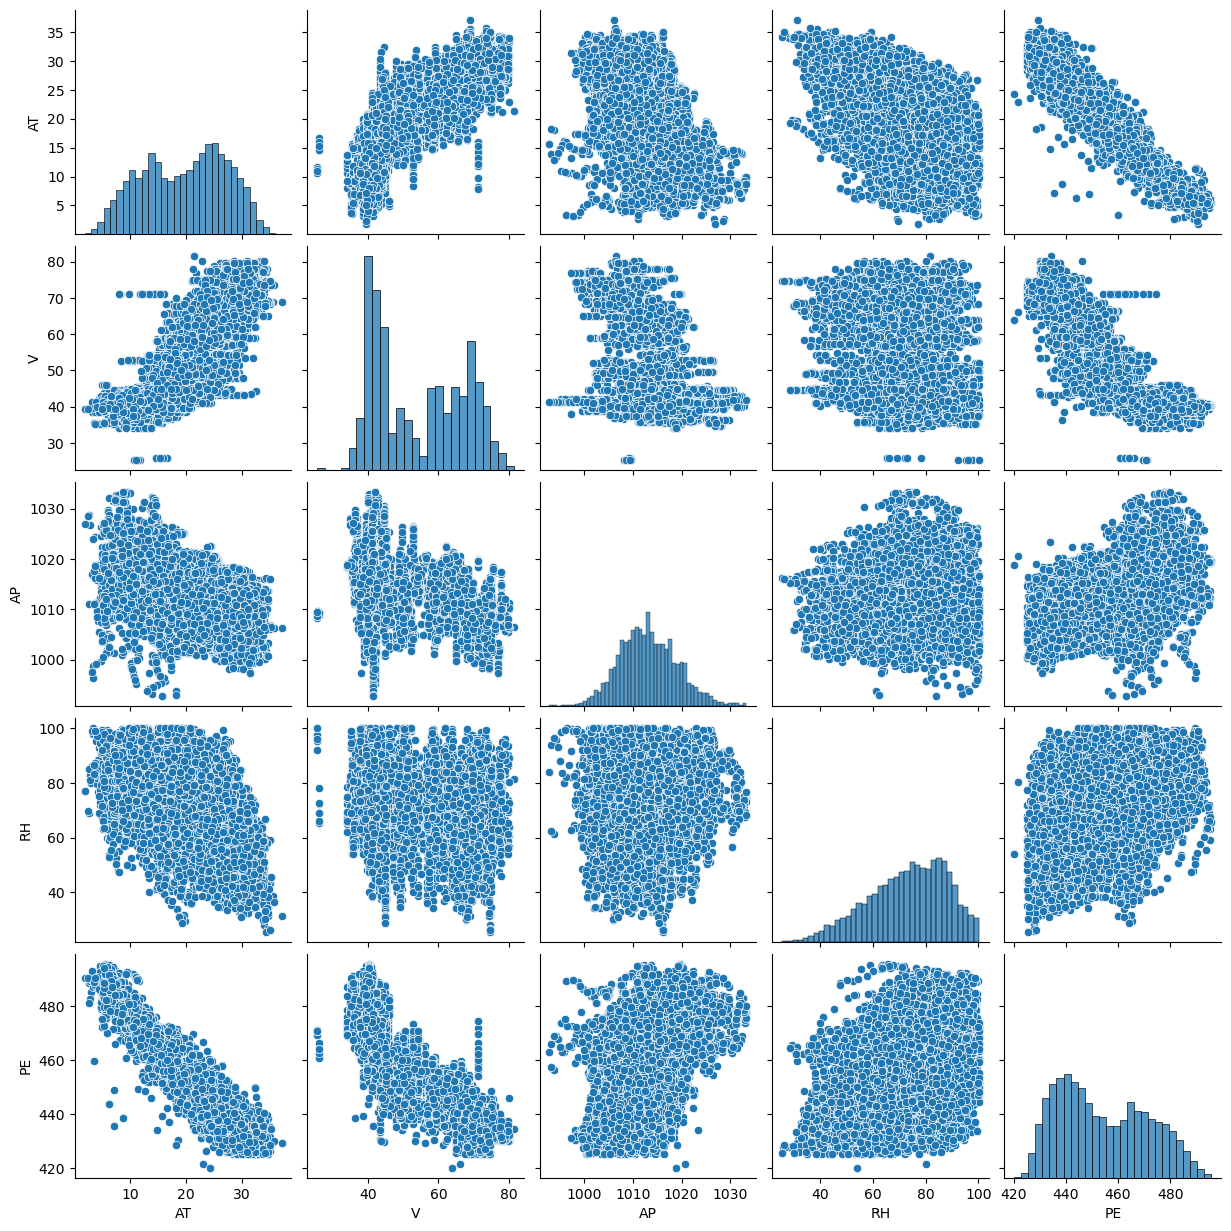

In [14]:
sns.pairplot(df)

AT vs PE
There appears to be a strong negative relation between Temperature and Energy Output. As AT increases, PE decreases.

V vs PE
There is a curved negative relationship between V and PE. At lower values of V, PE  is higher, but as V increases, PE decreases, but not linearly. So this suggests that they have a non-linear relationship.

AP vs PE
From the plot, we can see there is a positive relationship between AP and PE. But the relationship is also not very clear, indicating that maybe AP does not have a strong effect on PE.

RH vs PE
This relation also seems to be unclear, mostly negative as there is a downward trend. RH has a non-linear impact on PE.

These plots suggest that AT and V are likely the most influential predictors of PE, with AP and RH playing a less significant role.

#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [17]:
summary = pd.DataFrame({'Variable': ['Temperature (AT)', 'Exhaust Vacuum (V)', 'Ambient Pressure (AP)', 'Relative Humidity (RH)', 'Energy Output (PE)'],
    'Mean': [df['AT'].mean(), df['V'].mean(), df['AP'].mean(), df['RH'].mean(), df['PE'].mean()],
    'Median': [df['AT'].median(), df['V'].median(), df['AP'].median(), df['RH'].median(), df['PE'].median()],
    'Range': [df['AT'].max() - df['AT'].min(), df['V'].max() - df['V'].min(), df['AP'].max() - df['AP'].min(), df['RH'].max() - df['RH'].min(), df['PE'].max() - df['PE'].min()],
    'First Quartile': [df['AT'].quantile(0.25), df['V'].quantile(0.25), df['AP'].quantile(0.25), df['RH'].quantile(0.25), df['PE'].quantile(0.25)],
    'Third Quartile': [df['AT'].quantile(0.75), df['V'].quantile(0.75), df['AP'].quantile(0.75), df['RH'].quantile(0.75), df['PE'].quantile(0.75)],
    'Interquartile Range': [df['AT'].quantile(0.75) - df['AT'].quantile(0.25), df['V'].quantile(0.75) - df['V'].quantile(0.25), df['AP'].quantile(0.75) - df['AP'].quantile(0.25), df['RH'].quantile(0.75) - df['RH'].quantile(0.25), df['PE'].quantile(0.75) - df['PE'].quantile(0.25)]
})

summary

,Variable,Mean,Median,Range,First Quartile,Third Quartile,Interquartile Range
0,Temperature (AT),19.651231,20.345,35.30,13.5100,25.72,12.2100
1,Exhaust Vacuum (V),54.305804,52.080,56.20,41.7400,66.54,24.8000
2,Ambient Pressure (AP),1013.259078,1012.940,40.41,1009.1000,1017.26,8.1600
3,Relative Humidity (RH),73.308978,74.975,74.60,63.3275,84.83,21.5025
4,Energy Output (PE),454.365009,451.550,75.50,439.7500,468.43,28.6800


### (c) Simple Linear Regression

In [19]:
df1 = df[['AT', 'PE']]
df2 = df[['V', 'PE']]
df3 = df[['AP', 'PE']]
df4 = df[['RH', 'PE']]

[464.55117331 442.36028334 485.9386749  ... 429.02837879 443.88020731
 450.13360879]


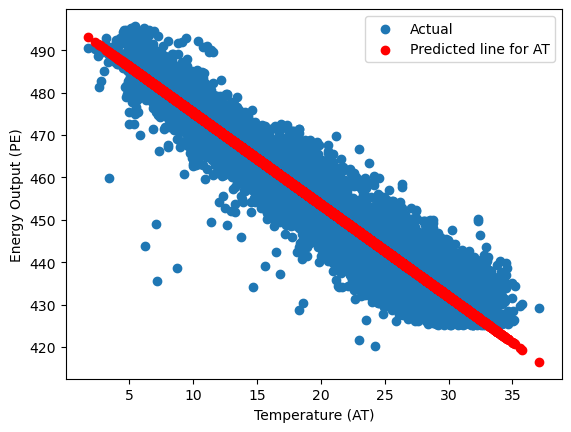

In [20]:
X_at = df1['AT']
y_at = df1['PE']
X_at = np.array(X_at).reshape(-1, 1)

lr_at = LinearRegression()
lr_at.fit(X_at, y_at)

y_at_pred = lr_at.predict(X_at)
print(y_at_pred)

plt.scatter(X_at, y_at, label='Actual')
plt.scatter(X_at, y_at_pred, color='red', label='Predicted line for AT')
plt.xlabel('Temperature (AT)')
plt.ylabel('Energy Output (PE)')
plt.legend()
plt.show()

In [21]:
X_at_with_intercept = sm.add_constant(X_at)
model_at = sm.OLS(y_at, X_at_with_intercept).fit()
print(model_at.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                 8.510e+04
Date:                Fri, 27 Sep 2024   Prob (F-statistic):               0.00
Time:                        23:07:08   Log-Likelihood:                -29756.
No. Observations:                9568   AIC:                         5.952e+04
Df Residuals:                    9566   BIC:                         5.953e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        497.0341      0.156   3177.280      0.0

Outliers detected at indices: [ 202  437  464  611  786  887  930 1438 1568 1615 2670 2787 2882 2912
 2936 3117 3383 3522 3645 3895 4218 4325 4346 4601 4633 6156 6555 6628
 6656 6720 6790 7375 7398 7427 7647 7664 7837 8187 8192 8362 8717 9477]
Number of outliers are: 42


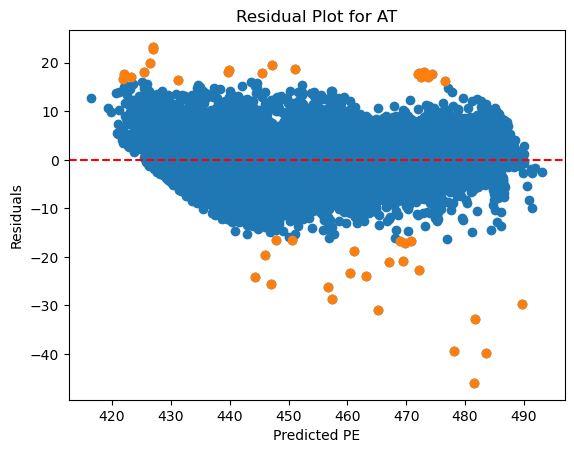

In [22]:
influence = OLSInfluence(model_at)
studentized_residuals = influence.resid_studentized_external

outliers = np.where(np.abs(studentized_residuals) > 3)[0]  # Outliers with studentized residual > 3
print(f'Outliers detected at indices: {outliers}')
print(f'Number of outliers are: {len(outliers)}')

residuals_at = y_at - y_at_pred
plt.scatter(y_at_pred, residuals_at, label="Residuals")
plt.scatter(y_at_pred[outliers], residuals_at[outliers], label="Outliers")
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted PE')
plt.ylabel('Residuals')
plt.title('Residual Plot for AT')
plt.show()

[469.02020342 444.25573874 471.77700232 ... 430.97404235 436.67454177
 444.7697182 ]


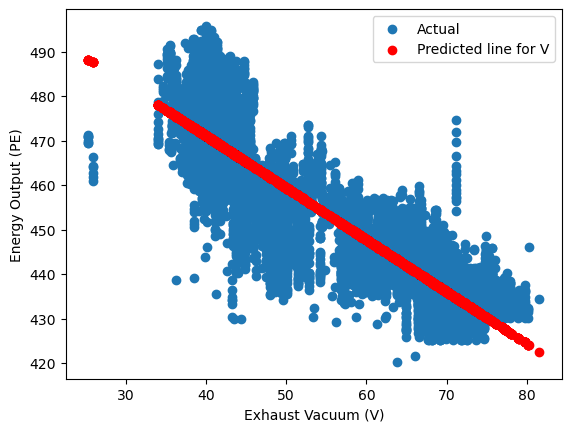

In [23]:
X_v = df2['V']
y_v = df2['PE']
X_v = np.array(X_v).reshape(-1, 1)

lr_v = LinearRegression()
lr_v.fit(X_v, y_v)

y_v_pred = lr_v.predict(X_v)
print(y_v_pred)

plt.scatter(X_v, y_v, label='Actual')
plt.scatter(X_v, y_v_pred, color='red', label='Predicted line for V')
plt.xlabel('Exhaust Vacuum (V)')
plt.ylabel('Energy Output (PE)')
plt.legend()
plt.show()

In [24]:
X_v_with_intercept = sm.add_constant(X_v)
model_v = sm.OLS(y_v, X_v_with_intercept).fit()
print(model_v.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.757
Model:                            OLS   Adj. R-squared:                  0.756
Method:                 Least Squares   F-statistic:                 2.972e+04
Date:                Fri, 27 Sep 2024   Prob (F-statistic):               0.00
Time:                        23:07:28   Log-Likelihood:                -33963.
No. Observations:                9568   AIC:                         6.793e+04
Df Residuals:                    9566   BIC:                         6.794e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        517.8015      0.378   1370.218      0.0

Outliers detected at indices: [ 182 1376 1438 1709 1773 1985 2217 2335 2385 2492 2993 3103 3117 3383
 3895 4070 5147 5283 5386 5418 5555 5852 6126 6289 6370 6573 6848 7664
 7752 8002 8432 8609 9089]
Number of outliers are: 33


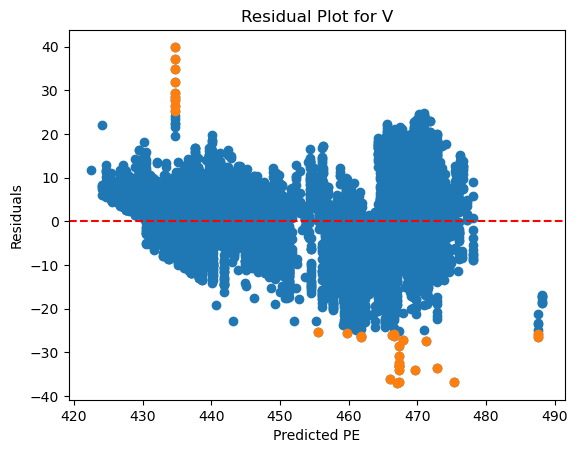

In [25]:
influence = OLSInfluence(model_v)
studentized_residuals = influence.resid_studentized_external

outliers = np.where(np.abs(studentized_residuals) > 3)[0]  # Outliers with studentized residual > 3
print(f'Outliers detected at indices: {outliers}')
print(f'Number of outliers are: {len(outliers)}')

residuals_v = y_v - y_v_pred
plt.scatter(y_v_pred, residuals_v, label="Residuals")
plt.scatter(y_v_pred[outliers], residuals_v[outliers], label="Outliers")
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted PE')
plt.ylabel('Residuals')
plt.title('Residual Plot for V')
plt.show()

[470.47189559 464.46771275 452.72752396 ... 453.85982643 455.26030581
 460.28117335]


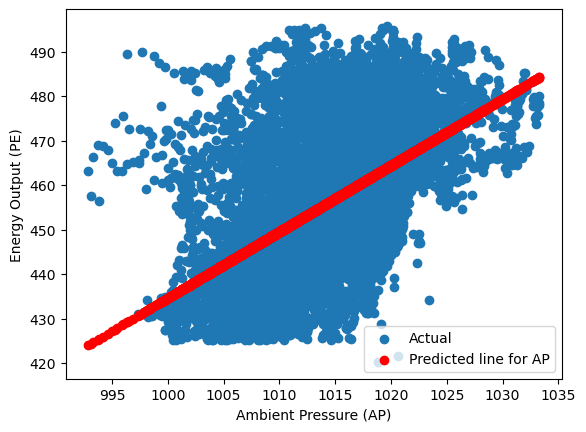

In [26]:
X_ap = df3['AP']
y_ap = df3['PE']
X_ap = np.array(X_ap).reshape(-1, 1)

lr_ap = LinearRegression()
lr_ap.fit(X_ap, y_ap)

y_ap_pred = lr_ap.predict(X_ap)
print(y_ap_pred)

plt.scatter(X_ap, y_ap, label='Actual')
plt.scatter(X_ap, y_ap_pred, color='red', label='Predicted line for AP')
plt.xlabel('Ambient Pressure (AP)')
plt.ylabel('Energy Output (PE)')
plt.legend()
plt.show()

In [27]:
X_ap_with_intercept = sm.add_constant(X_ap)
model_ap = sm.OLS(y_ap, X_ap_with_intercept).fit()
print(model_ap.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.269
Model:                            OLS   Adj. R-squared:                  0.269
Method:                 Least Squares   F-statistic:                     3516.
Date:                Fri, 27 Sep 2024   Prob (F-statistic):               0.00
Time:                        23:07:49   Log-Likelihood:                -39224.
No. Observations:                9568   AIC:                         7.845e+04
Df Residuals:                    9566   BIC:                         7.847e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1055.2610     25.459    -41.449      0.0

Outliers detected at indices: [ 618 1091 1290 1662 1735 1796 1907 1996 2047 2776 2972 3452 4002 4080
 4193 4598 4792 5238 6078 6229 6984 7031 7077 7091 7136 7182 7625 7941
 8827 9153]
Number of outliers are: 30


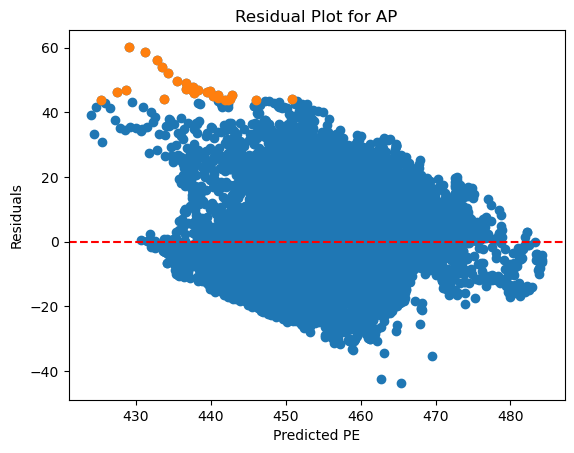

In [28]:
influence = OLSInfluence(model_ap)
studentized_residuals = influence.resid_studentized_external

outliers = np.where(np.abs(studentized_residuals) > 3)[0]  # Outliers with studentized residual > 3
print(f'Outliers detected at indices: {outliers}')
print(f'Number of outliers are: {len(outliers)}')

residuals_ap = y_ap - y_ap_pred
plt.scatter(y_ap_pred, residuals_ap, label="Residuals")
plt.scatter(y_ap_pred[outliers], residuals_ap[outliers], label="Outliers")
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted PE')
plt.ylabel('Residuals')
plt.title('Residual Plot for AP')
plt.show()

[454.30168414 447.8815742  462.94536658 ... 437.58388189 449.38977604
 451.8867386 ]


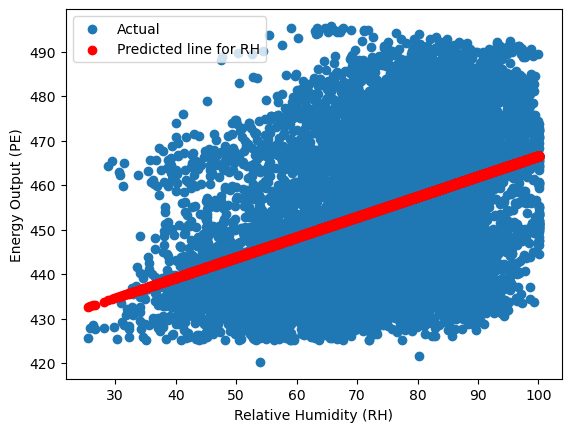

In [29]:
X_rh = df4['RH']
y_rh = df4['PE']
X_rh = np.array(X_rh).reshape(-1, 1)

lr_rh = LinearRegression()
lr_rh.fit(X_rh, y_rh)

y_rh_pred = lr_rh.predict(X_rh)
print(y_rh_pred)

plt.scatter(X_rh, y_rh, label='Actual')
plt.scatter(X_rh, y_rh_pred, color='red', label='Predicted line for RH')
plt.xlabel('Relative Humidity (RH)')
plt.ylabel('Energy Output (PE)')
plt.legend()
plt.show()

In [30]:
X_rh_with_intercept = sm.add_constant(X_rh)
model_rh = sm.OLS(y_rh, X_rh_with_intercept).fit()
print(model_rh.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.152
Model:                            OLS   Adj. R-squared:                  0.152
Method:                 Least Squares   F-statistic:                     1714.
Date:                Fri, 27 Sep 2024   Prob (F-statistic):               0.00
Time:                        23:08:11   Log-Likelihood:                -39933.
No. Observations:                9568   AIC:                         7.987e+04
Df Residuals:                    9566   BIC:                         7.988e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        420.9618      0.823    511.676      0.0

Outliers detected at indices: [4719 7900]
Number of outliers are: 2


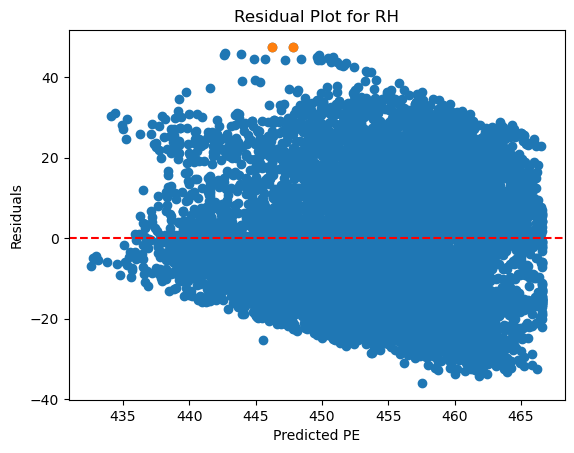

In [31]:
influence = OLSInfluence(model_rh)

studentized_residuals = influence.resid_studentized_external

outliers = np.where(np.abs(studentized_residuals) > 3)[0]  # Outliers with studentized residual > 3
print(f'Outliers detected at indices: {outliers}')
print(f'Number of outliers are: {len(outliers)}')

residuals_rh = y_rh - y_rh_pred
plt.scatter(y_rh_pred, residuals_rh, label="Residuals")
plt.scatter(y_rh_pred[outliers], residuals_rh[outliers], label="Outliers")
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted PE')
plt.ylabel('Residuals')
plt.title('Residual Plot for RH')
plt.show()

As we can see, in the linear regression models of all the predictors vs response, the p-value for the coefficient of predictors is always 0, and since the value is less than 0.5, we can conclude that there is a statistically significant association between all the predictors and response. 

Also, the plots of predictor vs response values show a clear linear relationship, which tells us that each predictor value significantly impacts the energy output. This plot shows the overall fit of the linear regression model.

The residual plot helps identify potential outliers or data points that deviate significantly from the model. Points outside the ±3 range of studentized residuals are considered potential outliers. These outliers can affect the accuracy of the regression model.

Since there are a significant number of outliers for AT, AP & V 42, 30 & 33 respectively, removing outliers for those predictors might help in creating a better and more accurate model. However since the number of outliers for RH is only 2, it won't make a significant difference.

### (d) Multiple Regression

In [34]:
X = df.drop(columns = 'PE')
y = df['PE']

multiple_lr = LinearRegression()
multiple_lr.fit(X, y)
multiple_lr_intercept = multiple_lr.intercept_
multiple_lr_coef = multiple_lr.coef_

y_pred = multiple_lr.predict(X)

In [35]:
# Define the predictors (X) and the response (y)
X = df.drop(columns='PE')  # Drop the response column
y = df['PE']  # Energy Output

# Add an intercept term (constant) for the regression model
X_with_intercept = sm.add_constant(X)

# Fit the multiple linear regression model using statsmodels
multiple_model = sm.OLS(y, X_with_intercept).fit()

# Print the model summary to get coefficients, p-values, and R-squared
multiple_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 27 Sep 2024   Prob (F-statistic):               0.00
Time:                        23:08:31   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.000     435.500     473.718
AT            -1.9775      0.015   -129.342      0.000      -2.007      -1.948
V             -0.2339      0.007    -32.122      0.000      -0.248      -0.220
AP             0.0621      0.009      6.564      0.000       0.044       0.081
RH            -0.1581      0.004    -37.918      0.000      -0.166      -0.150
==============================================================================
Omnibus:                      892.002   Durbin-Watson:                   2.033
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4086.777
Skew:                          -0.352   Prob(JB):                         0.00
Kurtosis:                       6.123   Cond. No.                     2.13e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.13e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Since, the p-values for all the variables is 0, which is less than 0.05, we can reject the null hypothesis for every variable and conclude that all the variables have a significant effect on PE.

### (e) 1c Compare to 1d

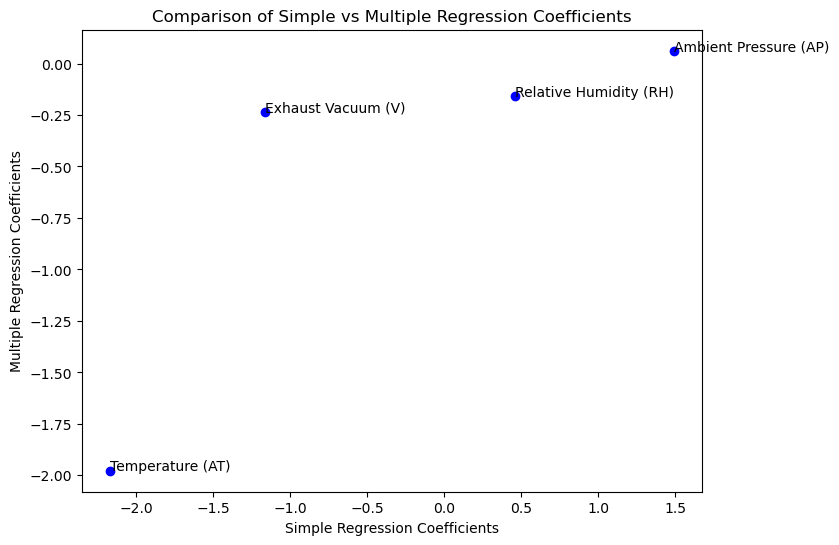

In [38]:
c_at = model_at.params.iloc[1]
c_v = model_v.params.iloc[1]
c_ap = model_ap.params.iloc[1]
c_rh = model_rh.params.iloc[1]

simple_coeffs = [c_at, c_v, c_ap, c_rh]
predictor_names = ['Temperature (AT)', 'Exhaust Vacuum (V)', 'Ambient Pressure (AP)', 'Relative Humidity (RH)']
plt.figure(figsize=(8, 6))
plt.scatter(simple_coeffs, multiple_lr_coef, color='blue')
for i, name in enumerate(predictor_names):
    plt.text(simple_coeffs[i], multiple_lr_coef[i], name)

plt.xlabel('Simple Regression Coefficients')
plt.ylabel('Multiple Regression Coefficients')
plt.title('Comparison of Simple vs Multiple Regression Coefficients')
plt.show()

In the simple regression model, the coefficient of AT is approximately -2.0 indicating a strong negative relationship between AT and PE. In the multiple regression model, the coefficient is also negative but less extreme than simple regression.

The coefficient of V is close to 0 for simple regression model and is slightly positive and in multiple regression model the coefficient for V is negative indicating that V has an inverse effect on PE.

The coefficient of AP & RH is positive in simple regression indicating positive relationship and for multiple regression, the coefficient of AP is positive while RH is negative.

The effect of AT remains consistently strong and negative across both models, indicating that temperature is a dominant predictor for energy output. Temperature (AT) is the most consistent predictor, while Exhaust Vacuum (V) and Relative Humidity (RH) show substantial changes in their effects, meaning that their relationships with the response variable are dependent on the other predictors.

### (f) Nonlinear Association

In [41]:
X_nonlinear_at = df['AT'].values.reshape(-1, 1)
y_nonlinear_at = df['PE']
X_nonlinear_v = df['V'].values.reshape(-1, 1)
y_nonlinear_v = df['PE']
X_nonlinear_ap = df['AP'].values.reshape(-1, 1)
y_nonlinear_ap = df['PE']
X_nonlinear_rh = df['RH'].values.reshape(-1, 1)
y_nonlinear_rh = df['PE']

In [42]:
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly_at = poly.fit_transform(X_nonlinear_at)

X_poly_with_intercept = sm.add_constant(X_poly_at)
cubic_model_at = sm.OLS(y_nonlinear_at, X_poly_with_intercept).fit()

print(cubic_model_at.summary())
p_values = cubic_model_at.pvalues 

p_value_X = p_values.iloc[1]  
p_value_X2 = p_values.iloc[2] 
p_value_X3 = p_values.iloc[3]

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                 3.299e+04
Date:                Fri, 27 Sep 2024   Prob (F-statistic):               0.00
Time:                        23:08:32   Log-Likelihood:                -29101.
No. Observations:                9568   AIC:                         5.821e+04
Df Residuals:                    9564   BIC:                         5.824e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        492.7281      0.673    732.248      0.0

Since the p values for both x2 and x3 are less than 0.05, the relationship between AT and PE is non-linear.

In [44]:
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly_v = poly.fit_transform(X_nonlinear_v)

X_poly_with_intercept = sm.add_constant(X_poly_v)
cubic_model_v = sm.OLS(y_nonlinear_v, X_poly_with_intercept).fit()

print(cubic_model_v.summary())
p_values = cubic_model_v.pvalues  

p_value_X = p_values.iloc[1] 
p_value_X2 = p_values.iloc[2]
p_value_X3 = p_values.iloc[3]

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.775
Model:                            OLS   Adj. R-squared:                  0.775
Method:                 Least Squares   F-statistic:                 1.098e+04
Date:                Fri, 27 Sep 2024   Prob (F-statistic):               0.00
Time:                        23:08:32   Log-Likelihood:                -33585.
No. Observations:                9568   AIC:                         6.718e+04
Df Residuals:                    9564   BIC:                         6.721e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        554.1468      9.151     60.557      0.0

Since the p values for x2 and x3 is not less than 0.05, p for x2 is > 0.05 the relationship between V and PE is not non-linear for the quadratic term but is non-linear for the cubic term.

In [46]:
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly_ap = poly.fit_transform(X_nonlinear_ap) 

X_poly_with_intercept = sm.add_constant(X_poly_ap)
cubic_model_ap = sm.OLS(y_nonlinear_ap, X_poly_with_intercept).fit()

print(cubic_model_ap.summary())
p_values = cubic_model_ap.pvalues 

p_value_X = p_values.iloc[1] 
p_value_X2 = p_values.iloc[2]
p_value_X3 = p_values.iloc[3]

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.275
Model:                            OLS   Adj. R-squared:                  0.275
Method:                 Least Squares   F-statistic:                     1813.
Date:                Fri, 27 Sep 2024   Prob (F-statistic):               0.00
Time:                        23:08:32   Log-Likelihood:                -39184.
No. Observations:                9568   AIC:                         7.837e+04
Df Residuals:                    9565   BIC:                         7.840e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0747      0.009      8.415      0.0

Since the p values for both x2 and x3 are less than 0.05, the relationship between AP and PE is non-linear.

In [48]:
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly_rh = poly.fit_transform(X_nonlinear_rh) 

X_poly_with_intercept = sm.add_constant(X_poly_rh)
cubic_model_rh = sm.OLS(y_nonlinear_rh, X_poly_with_intercept).fit()

print(cubic_model_rh.summary())
p_values = cubic_model_rh.pvalues 

p_value_X = p_values.iloc[1] 
p_value_X2 = p_values.iloc[2]
p_value_X3 = p_values.iloc[3]

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.154
Model:                            OLS   Adj. R-squared:                  0.153
Method:                 Least Squares   F-statistic:                     579.2
Date:                Fri, 27 Sep 2024   Prob (F-statistic):               0.00
Time:                        23:08:32   Log-Likelihood:                -39923.
No. Observations:                9568   AIC:                         7.985e+04
Df Residuals:                    9564   BIC:                         7.988e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        468.4135     10.545     44.422      0.0

Since the p values for both x2 and x3 are less than 0.05, the relationship between RH and PE is non-linear.

### (g) Interactions of Predictors

In [51]:
X = df[['AT', 'V', 'AP', 'RH']] 
y = df['PE']

poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_interactions = poly.fit_transform(X)

interaction_features = poly.get_feature_names_out(input_features=['AT', 'V', 'AP', 'RH'])
X_interactions_with_intercept = sm.add_constant(X_interactions)
interaction_model = sm.OLS(y, X_interactions_with_intercept).fit()

X_interactions_df = pd.DataFrame(X_interactions_with_intercept, columns=['Intercept'] + list(interaction_features))
interaction_model_with_names = sm.OLS(y, X_interactions_df).fit()
print(interaction_model_with_names.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Fri, 27 Sep 2024   Prob (F-statistic):               0.00
Time:                        23:08:32   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

Statistically Significant Terms (p <= 0.05):

V             0.000

AP            0.047

RH            0.042

AT V          0.000

AT RH         0.000

V AP          0.000

AP RH         0.034

Statistically Insignificant Terms (p > 0.05):

AT       0.067019

AT AP    0.452051

V RH     0.086194

### (h) Improvement

In [54]:
X = df[['AT', 'V', 'AP', 'RH']]
y = df['PE']
X_train ,X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 21)

X_train_with_intercept = sm.add_constant(X_train)
X_test_with_intercept = sm.add_constant(X_test)

baseline_model = sm.OLS(y_train, X_train_with_intercept).fit()
y_train_pred_baseline = baseline_model.predict(X_train_with_intercept)
y_test_pred_baseline = baseline_model.predict(X_test_with_intercept)

mse_train_baseline = mean_squared_error(y_train, y_train_pred_baseline)
mse_test_baseline = mean_squared_error(y_test, y_test_pred_baseline)

print("Baseline Model:")
print(f"Train MSE: {mse_train_baseline}")
print(f"Test MSE: {mse_test_baseline}")
print(baseline_model.summary())

Baseline Model:
Train MSE: 20.401114697413025
Test MSE: 21.633732481201093
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.930
Model:                            OLS   Adj. R-squared:                  0.930
Method:                 Least Squares   F-statistic:                 2.231e+04
Date:                Fri, 27 Sep 2024   Prob (F-statistic):               0.00
Time:                        23:08:32   Log-Likelihood:                -19600.
No. Observations:                6697   AIC:                         3.921e+04
Df Residuals:                    6692   BIC:                         3.924e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------

In [55]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

X_train_poly_with_intercept = sm.add_constant(X_train_poly)
X_test_poly_with_intercept = sm.add_constant(X_test_poly)

complex_model = sm.OLS(y_train, X_train_poly_with_intercept).fit()

y_train_pred_complex = complex_model.predict(X_train_poly_with_intercept)
y_test_pred_complex = complex_model.predict(X_test_poly_with_intercept)

mse_train_complex = mean_squared_error(y_train, y_train_pred_complex)
mse_test_complex = mean_squared_error(y_test, y_test_pred_complex)

print("Complex Model:")
print(f"Train MSE: {mse_train_complex}")
print(f"Test MSE: {mse_test_complex}")
print(complex_model.summary())

Complex Model:
Train MSE: 17.669340015008387
Test MSE: 19.141740820120724
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.940
Model:                            OLS   Adj. R-squared:                  0.939
Method:                 Least Squares   F-statistic:                     7422.
Date:                Fri, 27 Sep 2024   Prob (F-statistic):               0.00
Time:                        23:08:32   Log-Likelihood:                -19119.
No. Observations:                6697   AIC:                         3.827e+04
Df Residuals:                    6682   BIC:                         3.837e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------

In [56]:
significant_indices = np.where(complex_model.pvalues <= 0.05)[0] 

X_train_poly_refined = X_train_poly_with_intercept[:, significant_indices]
X_test_poly_refined = X_test_poly_with_intercept[:, significant_indices]

refined_model = sm.OLS(y_train, X_train_poly_refined).fit()

y_train_pred_refined = refined_model.predict(X_train_poly_refined)
y_test_pred_refined = refined_model.predict(X_test_poly_refined)

mse_train_refined = mean_squared_error(y_train, y_train_pred_refined)
mse_test_refined = mean_squared_error(y_test, y_test_pred_refined)

print("Refined Model (After Removing Insignificant Variables):")
print(f"Train MSE: {mse_train_refined}")
print(f"Test MSE: {mse_test_refined}")
print(refined_model.summary())

Refined Model (After Removing Insignificant Variables):
Train MSE: 19.73590686798715
Test MSE: 21.236763377384005
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.933
Model:                            OLS   Adj. R-squared:                  0.932
Method:                 Least Squares   F-statistic:                 1.155e+04
Date:                Fri, 27 Sep 2024   Prob (F-statistic):               0.00
Time:                        23:08:32   Log-Likelihood:                -19489.
No. Observations:                6697   AIC:                         3.900e+04
Df Residuals:                    6688   BIC:                         3.906e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------

The Test MSE has decreased from 21.63 in the baseline model to 19.14 in the complex model, indicating that the complex model performs better when predicting the Energy Output for the test set. 

The Train MSE has also improved, from 20.40 to 17.67, showing that the complex model fits the training data more effectively. 

Since both Test and Train MSEs have improved, this suggests that the complex model generalizes better and is not overfitting.

After removing insignificant variables from the complex model, the refined model results in a Test MSE of 21.24 and a Train MSE of 19.73. This shows that the refined model does not perform as well as the full complex model. 
So this means that although some of the terms that were removed were statistically insignificant, they contributed to the model's performance.

### (i) KNN

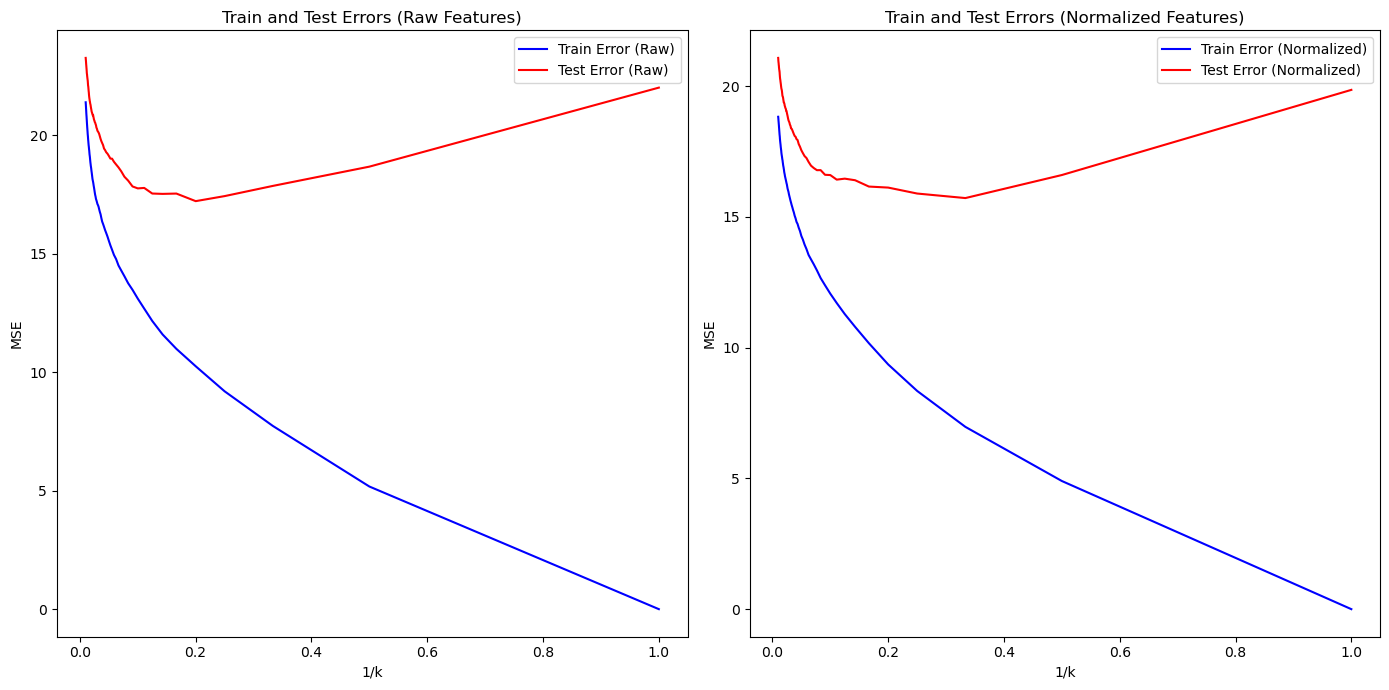

In [59]:
X = df[['AT', 'V', 'AP', 'RH']]
y = df['PE']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=21)

scaler = StandardScaler()
X_train_normalized = scaler.fit_transform(X_train)
X_test_normalized = scaler.transform(X_test)

train_errors_raw = []
test_errors_raw = []
train_errors_normalized = []
test_errors_normalized = []

for k in range(1, 101):
    knn_raw = KNeighborsRegressor(n_neighbors=k)
    knn_raw.fit(X_train, y_train)
    
    y_train_pred_raw = knn_raw.predict(X_train)
    y_test_pred_raw = knn_raw.predict(X_test)
    
    train_errors_raw.append(mean_squared_error(y_train, y_train_pred_raw))
    test_errors_raw.append(mean_squared_error(y_test, y_test_pred_raw))
    
    knn_normalized = KNeighborsRegressor(n_neighbors=k)
    knn_normalized.fit(X_train_normalized, y_train)
    
    y_train_pred_normalized = knn_normalized.predict(X_train_normalized)
    y_test_pred_normalized = knn_normalized.predict(X_test_normalized)
    
    train_errors_normalized.append(mean_squared_error(y_train, y_train_pred_normalized))
    test_errors_normalized.append(mean_squared_error(y_test, y_test_pred_normalized))

k_values = np.arange(1, 101)

plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)
plt.plot(1 / k_values, train_errors_raw, label="Train Error (Raw)", color="blue")
plt.plot(1 / k_values, test_errors_raw, label="Test Error (Raw)", color="red")
plt.xlabel("1/k")
plt.ylabel("MSE")
plt.title("Train and Test Errors (Raw Features)")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(1 / k_values, train_errors_normalized, label="Train Error (Normalized)", color="blue")
plt.plot(1 / k_values, test_errors_normalized, label="Test Error (Normalized)", color="red")
plt.xlabel("1/k")
plt.ylabel("MSE")
plt.title("Train and Test Errors (Normalized Features)")
plt.legend()

plt.tight_layout()
plt.show()

### (j ) Compare KNN and Linear

In [61]:
best_k_index = np.argmin(test_errors_raw)
best_k_raw = best_k_index + 1
best_knn_raw_test_mse = test_errors_raw[best_k_index]

print(f"The best value of k for raw features is: {best_k_raw} with a Test MSE of {best_knn_raw_test_mse}")

best_k_normalized_index = np.argmin(test_errors_normalized)
best_k_normalized = best_k_normalized_index + 1
best_knn_test_mse_normalized = test_errors_normalized[best_k_normalized_index]

print(f"The best value of k for normalized features is {best_k_normalized} with a Test MSE of {best_knn_test_mse_normalized}")

The best value of k for raw features is: 5 with a Test MSE of 17.212169168930686
The best value of k for normalized features is 3 with a Test MSE of 15.723274464956075


KNN Normalized Model (k = 3): Test MSE = 15.72.
KNN Raw Features Model (k = 5): Test MSE = 17.21.
Complex Linear Regression Model: Test MSE = 19.14.

So, for the 2 knn models, we see that the normalized knn model gives us better results, i.e a lower mean square test error rate of 15.72 at k =3, which is less than raw features knn model that gives an MSE value of 17.21 at k =5.

For k = 3 (best k), the KNN normalized model gives Test MSE = 15.72
& the test MSE for complex linear regression model(lowest test MSE was found for the complex model) is 19.14. So, the KNN normalized model gives a lower test error compared to complex linear regression model.

The lower Test MSE in the KNN model suggests that KNN captures the relationship between the predictors and the response variable(PE) more effectively, at least when generalizing to the test set.

So, for this dataset, KNN regression with k = 3, gives better predictive performance on the test set than the complex linear regression model. The non-parametric nature of KNN likely allows it to capture non-linear patterns that linear regression misses, resulting in lower test error.

## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

In this case, flexible methods would be better than an inflexible method.

Flexible methods, such as KNN have the ability to model complex relationships and capture the data patterns, whereas inflexible methods such as linear regression, assume the form of the relationship between the predictors and respnse and hence become more constrained and might not fully capture the complex relationships, especially when sample size, n is large. And since the number of predictors, p is small for a large n, the risk of overfitting is also reduced in the case of flexible methods.

### (b) The number of predictors p is extremely large, and the number of observations n is small.

In this case, an inflexible method would be better than a flexible method.

Because, flexible methods have a higher risk of overfitting when the number of predictors, p is large and n is small. There is a risk that a flexible method may also fit the noise in the data rather than capturing the true data patterns.
However, with inflexible methods, they have a more constrained approach and impose assumptions like linearity that help avoid overfitting.

### (c) The relationship between the predictors and response is highly non-linear.

Flexible method would be a better choice in this case.

Unlike the inflexible methods,flexible methods do not make any strong assumptions about the form of the relationship between the predictors and the response, they can adapt to non linear patterns better.

### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

An inflexible method would be a better choice for this.
When the variance of the error terms is high, it means that there is a lot of noise in the data. and a flexible method is more likely to fit noise in the data as it is more sensitive to fluctuations in the data. 
However, inflexible methods tend to smooth out the data by making strong assumptions about the form of the relation between predictors and responses. So, in the presence of high variance, a more constrained method would perform better, as it reduces the risk of capturing random errors or noise.

## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

In [74]:
observations = np.array([
    [0, 3, 0],  
    [2, 0, 0],  
    [0, 1, 3],  
    [0, 1, 2],  
    [-1, 0, 1], 
    [1, 1, 1]  
])
test_point = np.array([0, 0, 0])

distances = np.sqrt(np.sum((observations - test_point)**2, axis=1))
for i, distance in enumerate(distances, start=1):
    print(f"Distance between Observation {i} and the test point: {distance:.2f}")

Distance between Observation 1 and the test point: 3.00
Distance between Observation 2 and the test point: 2.00
Distance between Observation 3 and the test point: 3.16
Distance between Observation 4 and the test point: 2.24
Distance between Observation 5 and the test point: 1.41
Distance between Observation 6 and the test point: 1.73


### (b) What is our prediction with K = 1? Why?

According to our calculation of the distance between each observation and the test point, (X1 = X2 = X3 = 0), we need to see which observation has the smallest distance. 
Observation 5 has the smallest distance from the test point, which is 1.41.
The class of observation 5 is green.
So, the KNN model with k = 1 will predict green for the test point X1 = X2 = X3 = 0. as it is the nearest neighbor

### (c) What is our prediction with K = 3? Why?

For k=3, we need to consider the three closest neighbors from the distances that we have calculated.
The three nearest neighbors are:
observation 5 - 1.41 Green
observation 6 - 1.73 Red
observation 2 - 2.00 Red

So among these three nearest neighbors, we have 2 observations that have class Red and one Green. So the majority class is Red.
Hence, for k=3, the model will predict Red as the class.

### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

In the case that the decision boundary is non linear, smaller values of k would yield better results.
Smaller values of k allow knn to fit the data more closely and is more flexible. Since k is small. the prediction will be based on only a few nearby points, giving the model the ability to follow the non liniearities in the decision boundary. Large k would make the model more inflexible and will smooth out the decision boundary and may also cause underfitting leading to less accurate predictions.

#### CITATIONS & REFERENCES 

1. (1.b, 1.c, 1.d)Took help from google and youtube to understand what interquartile ranges are and how to perform simple and multiple regression on a given dataset
https://www150.statcan.gc.ca/n1/edu/power-pouvoir/ch12/5214890-eng.htm
https://www.geeksforgeeks.org/ml-linear-regression/
https://www.youtube.com/watch?v=feDJkDaNuOk
https://www.youtube.com/watch?v=wH_ezgftiy0

2. (1.c) Searched on google about what does being statistically significant mean?
https://www.investopedia.com/terms/s/statistical-significance.asp
Asked chatgpt how do we calculate p value for a simple regression model?
response: The p-value in a simple linear regression model is used to test the significance of the relationship between the independent variable (predictor) and the dependent variable (response). It helps determine whether the slope of the regression line is significantly different from zero.
You can use statistical software (such as Python's scipy.stats.ttest() function or R's pt() function) to calculate the p-value.
import numpy as np
import statsmodels.api as sm
x = np.array([10, 12, 13, 15, 16])
y = np.array([20, 22, 24, 27, 29])
X = sm.add_constant(x)
model = sm.OLS(y, X).fit()
print(model.summary())

3. (1.d) referred to the same site to understand about null hypothesis
https://www.investopedia.com/terms/s/statistical-significance.asp

4. (1.f) took reference from google about ploynomial regression
I searched for: how do we fit a polynomial form of linear regression?
https://www.analyticsvidhya.com/blog/2021/07/all-you-need-to-know-about-polynomial-regression/

5. (1.g) Took reference from chatgpt
prompt: If i have to run a full linear regression model with all pairwise interaction  terms. what steps should i follow?
response: To run a full linear regression model with all pairwise interaction terms, you need to follow a series of steps to create the interaction terms and then fit the linear regression model. Pairwise interaction terms allow you to model the combined effect of two variables on the dependent variable, which might not be captured by the individual terms alone.
Steps to Run a Linear Regression with Pairwise Interaction Terms:
Step 1: Prepare Your Data
You need to have a dataset with your independent variables 
Step 2: Generate Pairwise Interaction Terms
Pairwise interaction terms are created by multiplying each pair of independent variables 
In the general case, for a dataset with multiple variables, pairwise interaction terms for each combination of independent variables are created.
Step 3: Fit a Full Linear Regression Model
The model will include the original terms and all pairwise interaction terms. If you have two variables 
Step 4: Use Software to Generate Interaction Terms and Fit the Model
Most statistical software (e.g., Python’s scikit-learn, R, or statsmodels) can automatically generate interaction terms and fit a linear regression model.
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
data = {
    'x1': [1, 2, 3, 4, 5],
    'x2': [2, 3, 4, 5, 6],
    'x3': [3, 4, 5, 6, 7],
    'y': [5, 7, 9, 11, 13]
}
df = pd.DataFrame(data)
X = df[['x1', 'x2', 'x3']]
y = df['y']                  
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)
X_poly = poly.fit_transform(X)
model = LinearRegression()
model.fit(X_poly, y)
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)
y_pred = model.predict(X_poly)
Step 5: Evaluate the Model
After fitting the model, evaluate it using metrics such as R-squared, Mean Squared Error (MSE), or residual analysis to check if adding the interaction terms improves the model’s performance.
Important Notes:
Scaling: It’s often a good idea to scale your data when using interaction terms, especially if the features are on different scales.
Overfitting: Be cautious of overfitting when adding many interaction terms, especially with large numbers of features. Regularization techniques such as Ridge or Lasso regression can help control overfitting.
Model Interpretation: Interaction terms make the model more complex to interpret